In [ ]:
# !pip install keras-cv==0.6.1 keras-core==0.1.0 tensorflow==2.13.1 tensorflow-datasets==4.9.7

In [1]:
import time
import keras_cv
from tensorflow import keras
import matplotlib.pyplot as plt

In [2]:
def plot_images(images):
    plt.figure(figsize=(20, 20))
    for i in range(len(images)):
        ax = plt.subplot(1, len(images), i + 1)
        plt.imshow(images[i])
        plt.axis("off")

In [3]:
keras.mixed_precision.set_global_policy("mixed_float16")
model = keras_cv.models.StableDiffusion(jit_compile=True)

By using this model checkpoint, you acknowledge that its usage is subject to the terms of the CreativeML Open RAIL-M license at https://raw.githubusercontent.com/CompVis/stable-diffusion/main/LICENSE


In [ ]:
# Let's make sure to warm up the model
images = model.text_to_image(
    "Golden gate bridge in the style of Starry Night",
    batch_size=3,
)
plot_images(images)


32/50 ━━━━━━━━━━━━━━━━━━━━ 33:40 112s/step

50/50 [==============================] - 28s 554ms/step
XLA + mixed precision: 28.89 seconds


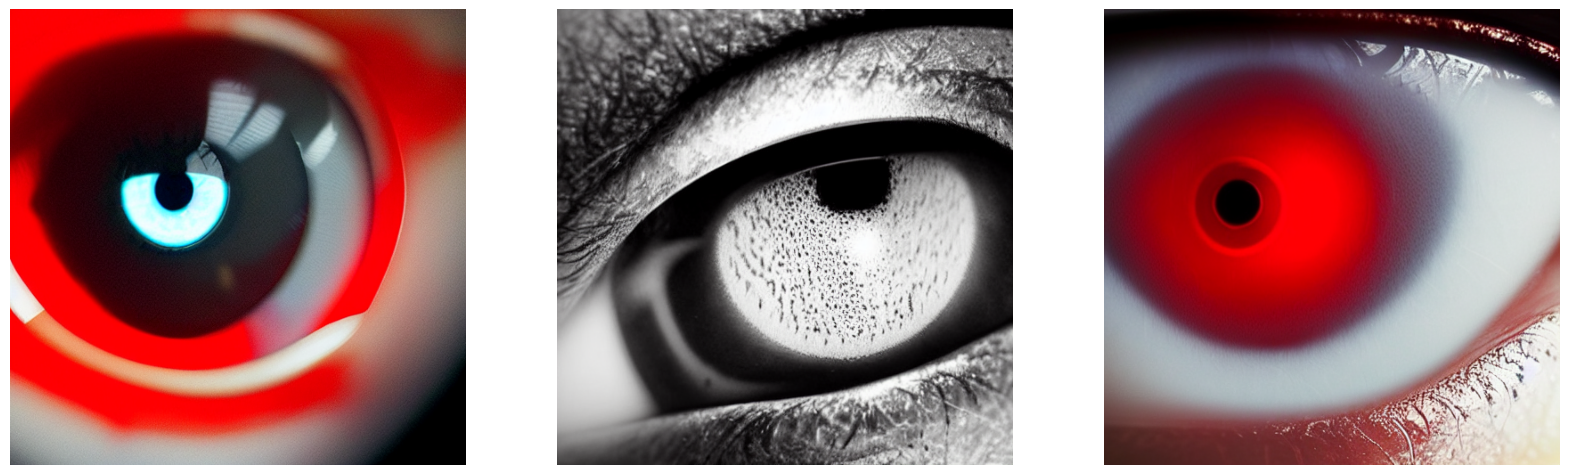

In [ ]:
start = time.time()
images = model.text_to_image(
    "a close up of a person's eye with a red light, robot eye, robotic eye,"
    " cyborg eyes, eye cyberpunk bionics, robotic eyes, robot eyes, glowing "
    "white mechanical eye, cybernetic eye, glowing mechanical eye, glowing "
    "mechanical eye camera, android eyes, techno eye, human with one robot "
    "eye, cybernetic eyes implants, open robotic eyes",
    batch_size=3,
)
end = time.time()
plot_images(images)

print(f"XLA + mixed precision: {(end - start):.2f} seconds")